In [1]:
""" Import section """
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Opening files to analyze

In [2]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

## DMSO Group

In [3]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso  = create_combined_dataframe("dataset_t6_grouped/results/G0")
dmso.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso_highest_pbopdy = dmso.loc[dmso.groupby('image')['pbody_number'].idxmax()]
dmso_highest_pbopdy.tail(60)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
582,W0082F0002T0006Z000C1N151.png,14,30.166926,30.384852,17.621077,18.370207,DMSO,DMSO
523,W0082F0002T0006Z000C1N152.png,9,15.299378,17.473632,12.196866,13.832065,DMSO,DMSO
460,W0082F0002T0006Z000C1N153.png,4,21.716317,21.321122,19.366809,19.695328,DMSO,DMSO
308,W0082F0002T0006Z000C1N154.png,14,52.811247,53.188336,14.195958,14.128291,DMSO,DMSO
560,W0082F0002T0006Z000C1N156.png,9,45.651831,46.132974,10.033206,10.234657,DMSO,DMSO
739,W0082F0002T0006Z000C1N162.png,13,9.016816,8.400369,18.860760,20.080911,DMSO,DMSO
159,W0082F0002T0006Z000C1N19.png,7,63.970563,61.147552,12.358747,11.443836,DMSO,DMSO
684,W0082F0002T0006Z000C1N21.png,8,53.912650,55.723348,10.914597,10.558391,DMSO,DMSO
123,W0082F0002T0006Z000C1N30.png,7,62.780625,58.832797,9.280097,15.590544,DMSO,DMSO
909,W0082F0002T0006Z000C1N35.png,17,41.839969,41.666434,9.760894,9.811727,DMSO,DMSO


## Group 1

In [4]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1  = create_combined_dataframe("dataset_t6_grouped/results/G1")
# g1.head(50)

In [5]:
""" check for nan values on g1 dataframe """
g1.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [6]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2  = create_combined_dataframe("dataset_t6_grouped/results/G2")
# g2.head(50)


In [7]:
""" check for nan values on g2 dataframe """
g2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [8]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3  = create_combined_dataframe("dataset_t6_grouped/results/G3")
# g3.head(50)

In [9]:
""" check for nan values on g3 dataframe """
g3.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [10]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4  = create_combined_dataframe("dataset_t6_grouped/results/G4")
# g4.head(50)

In [11]:
""" check for nan values on g4 dataframe """
g4.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [12]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5  = create_combined_dataframe("dataset_t6_grouped/results/G5")
# g5.head(50)

In [13]:
""" check for nan values on g1 dataframe """
g5.isna().sum()

image            0
pbody_number     0
dist_nuclei     95
dist_mito        0
nuclei_std      95
mito_std         0
medicine         0
group            0
dtype: int64

# Graphing Section

In [14]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [15]:
""" Calling function for each dataframe """
group_summary, med_summary, combined_df = summarize_pbodies_by_group(dmso, g1, g2, g3, g4, g5)
group_summary.head(50)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,910,37.644022,35.330905,17.473040,17.331990
1,G1,1486,32.502657,29.817761,16.784150,16.022025
2,G2,2963,33.930727,33.009990,17.456573,17.135764
3,G3,1320,43.079189,41.130336,21.145230,21.348172
4,G4,7149,37.829421,34.953191,18.533707,18.679874
5,G5,5512,35.262373,29.232626,26.448808,24.425268


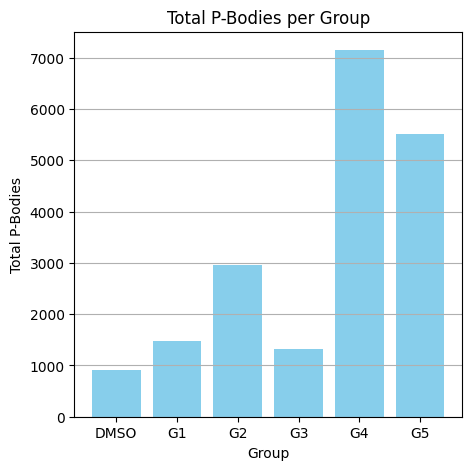

In [16]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary['group'], group_summary['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary['group'])
plt.grid(axis='y')
plt.show()

0     910
1    1486
2    2963
3    1320
4    7149
5    5512
Name: total_pbodies, dtype: int64


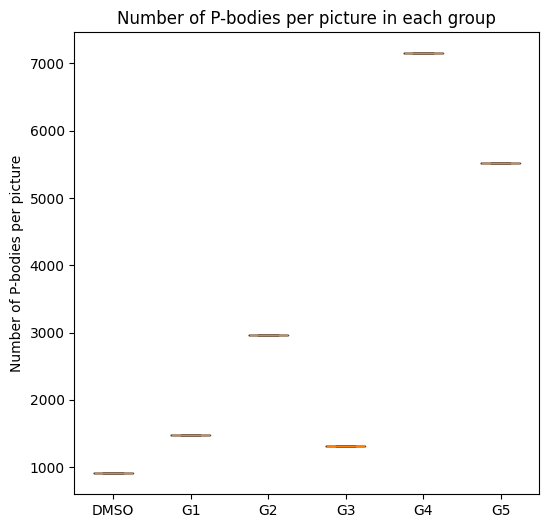

In [17]:
"""
    Create a boxplot that shows number of pbodies (n_pbody) per picture in each group using the group_summary table
"""
print(group_summary['total_pbodies'])
fig = plt.figure(figsize =(6,6))
plt.boxplot([group_summary['total_pbodies'][group_summary['group'] == g].values for g in group_summary['group']], 
            tick_labels=group_summary["group"], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in each group')
plt.show()

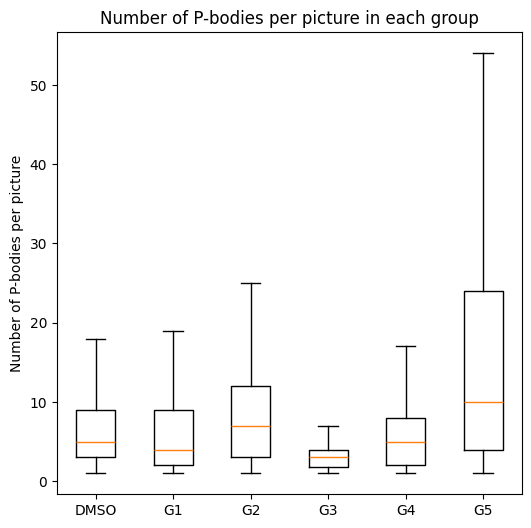

In [18]:
# Get unique group labels
groups = combined_df['group'].unique()

# Prepare data for each group
data_per_group = [
    combined_df.loc[combined_df['group'] == g, 'pbody_number'].values
    for g in groups
]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data_per_group, tick_labels=groups, showfliers=False)
ax.set_ylabel('Number of P-bodies per picture')
ax.set_title('Number of P-bodies per picture in each group')
plt.show()


# Opening files to analyze2

In [19]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

## DMSO Group

In [20]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso2  = create_combined_dataframe("dataset_t6_grouped/results2/G0")
dmso2.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso2_highest_pbopdy = dmso2.loc[dmso2.groupby('image')['pbody_number'].idxmax()]
dmso2_highest_pbopdy.tail(60)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
332,W0082F0002T0006Z000C1N151.png,8,11.733251,9.882962,12.500570,12.642233,DMSO,DMSO
297,W0082F0002T0006Z000C1N152.png,6,15.299378,17.473632,14.542559,16.117933,DMSO,DMSO
258,W0082F0002T0006Z000C1N153.png,2,23.384874,23.100162,18.552667,18.580119,DMSO,DMSO
175,W0082F0002T0006Z000C1N154.png,7,48.844271,49.213730,14.344759,14.302250,DMSO,DMSO
317,W0082F0002T0006Z000C1N156.png,3,54.207772,32.749616,13.799376,5.068324,DMSO,DMSO
428,W0082F0002T0006Z000C1N162.png,9,8.708469,8.093601,21.109821,22.280214,DMSO,DMSO
83,W0082F0002T0006Z000C1N19.png,4,35.129429,34.318887,7.269905,6.963741,DMSO,DMSO
393,W0082F0002T0006Z000C1N21.png,5,54.014613,55.824969,11.794726,11.412521,DMSO,DMSO
66,W0082F0002T0006Z000C1N30.png,3,63.126991,59.179077,9.337157,15.451516,DMSO,DMSO
520,W0082F0002T0006Z000C1N35.png,14,40.833315,40.663217,11.094811,9.661558,DMSO,DMSO


## Group 1

In [21]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1_2  = create_combined_dataframe("dataset_t6_grouped/results2/G1")
# g1_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [22]:
""" check for nan values on g1 dataframe """
g1_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [23]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2_2  = create_combined_dataframe("dataset_t6_grouped/results2/G2")
# g2_2.head(50)


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [24]:
""" check for nan values on g2 dataframe """
g2_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [25]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3_2  = create_combined_dataframe("dataset_t6_grouped/results2/G3")
# g3_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [26]:
""" check for nan values on g3 dataframe """
g3_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [27]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4_2  = create_combined_dataframe("dataset_t6_grouped/results2/G4")
# g4_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [28]:
""" check for nan values on g4 dataframe """
g4_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [29]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5_2  = create_combined_dataframe("dataset_t6_grouped/results2/G5")
# g5_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [30]:
""" check for nan values on g1 dataframe """
g5_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     2
dist_mito       0
nuclei_std      2
mito_std        0
medicine        0
group           0
dtype: int64

# Graphing Section 2

In [31]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [32]:
""" Calling function for each dataframe """
group_summary_2, med_summary_2, combined_df_2 = summarize_pbodies_by_group(dmso2, g1_2, g2_2, g3_2, g4_2, g5_2)
group_summary_2.head(10)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,521,36.472406,33.969350,17.703992,17.291532
1,G1,951,32.725225,29.590071,16.613769,15.855388
2,G2,1710,34.568666,33.536094,18.125019,17.621870
3,G3,670,43.931080,42.227706,21.025387,20.882480
4,G4,3813,37.920477,34.950767,18.254700,18.375275
5,G5,1457,27.214761,21.908473,23.520467,21.208111


In [33]:
med_summary_2.head(10)

,group,medicine,total_pbodies,mean_dist_nuclei,mean_dist_mito
0,DMSO,DMSO,521,36.472406,33.969350
1,G1,T0374,96,30.573971,31.979459
2,G1,T0374L,133,31.055894,31.732647
3,G1,T1912,90,31.922927,29.387147
4,G1,T1995,87,31.750645,29.237069
5,G1,T6020,71,32.798523,24.672185
6,G1,T7394,474,33.949556,29.344924
7,G2,T0860,241,32.559777,31.646980
8,G2,T1448,279,35.493652,34.520715
9,G2,T1656,226,36.119920,34.061069


In [34]:
combined_df_2.head(10)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
0,W0082F0003T0006Z000C1N39.png,1,49.318659,49.391425,5.071454,5.254271,DMSO,DMSO
1,W0082F0003T0006Z000C1N39.png,2,39.175751,38.882883,5.071454,5.254271,DMSO,DMSO
2,W0082F0002T0006Z000C1N4.png,1,38.536050,39.104340,1.615809,2.150513,DMSO,DMSO
3,W0082F0002T0006Z000C1N4.png,2,35.900325,35.258580,1.615809,2.150513,DMSO,DMSO
4,W0082F0002T0006Z000C1N4.png,3,34.661141,34.063965,1.615809,2.150513,DMSO,DMSO
5,W0082F0002T0006Z000C1N53.png,1,43.576494,43.814690,8.027732,7.919945,DMSO,DMSO
6,W0082F0002T0006Z000C1N53.png,2,49.005028,48.895662,8.027732,7.919945,DMSO,DMSO
7,W0082F0002T0006Z000C1N53.png,3,39.612105,39.547002,8.027732,7.919945,DMSO,DMSO
8,W0082F0002T0006Z000C1N53.png,4,36.671560,36.664996,8.027732,7.919945,DMSO,DMSO
9,W0082F0002T0006Z000C1N53.png,5,59.138072,58.721370,8.027732,7.919945,DMSO,DMSO


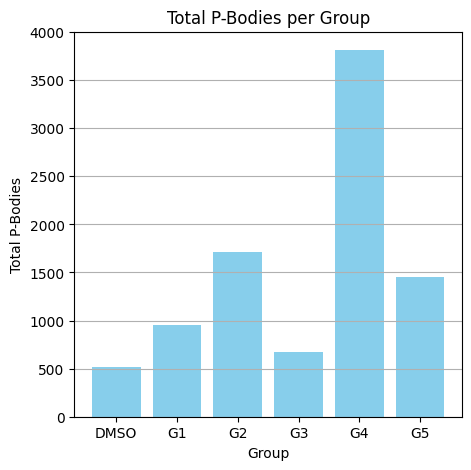

In [35]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary_2['group'], group_summary_2['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary_2['group'])
plt.grid(axis='y')
plt.show()

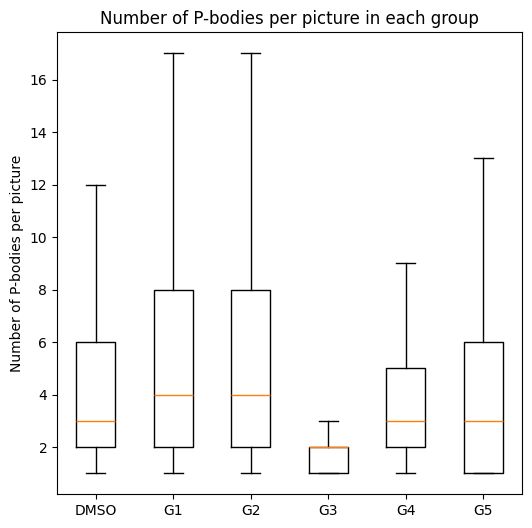

In [36]:
# Get unique group labels
groups = combined_df_2['group'].unique()

# Prepare data for each group
data_per_group_2 = [
    combined_df_2.loc[combined_df_2['group'] == g, 'pbody_number'].values
    for g in groups
]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data_per_group_2, tick_labels=groups, showfliers=False)
ax.set_ylabel('Number of P-bodies per picture')
ax.set_title('Number of P-bodies per picture in each group')
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/4016253703.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


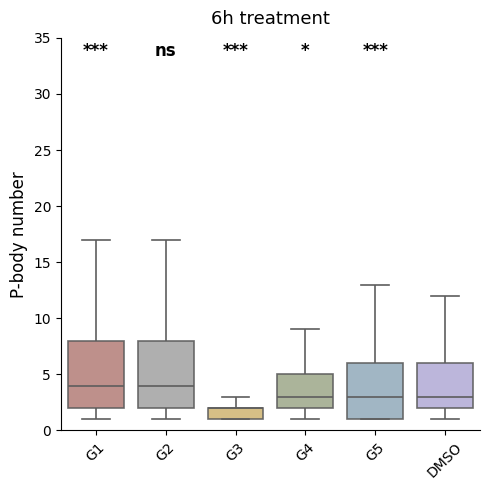

In [37]:
# --- reorder groups so DMSO is last ---
order = ["G1", "G2", "G3", "G4", "G5", "DMSO"]

# --- define colors matching your reference (tune if needed) ---
colors = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"]

# --- plot ---
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="pbody_number",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)

# labels and aesthetics
plt.ylabel("P-body number", fontsize=12)
plt.xlabel("")
plt.title("6h treatment", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()

# --- add significance stars manually (adjust y-coordinates to your data) ---
annotations = ["***", "ns", "***", "*", "***"]
y_max = combined_df_2["pbody_number"].max()
for i, (label, g) in enumerate(zip(annotations, order[:-1])):
    plt.text(i, y_max + 1, label, ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.ylim(0, y_max + 3)
plt.tight_layout()
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/3657349770.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


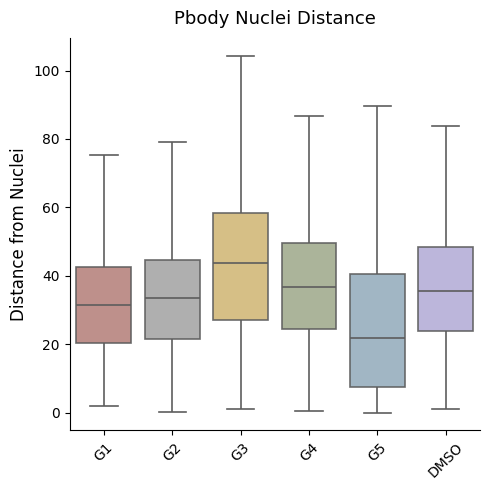

In [41]:
""" 
    Create A boxplot that shows the mean distance from nuclei per picture in each group using the combined_df_2 table
"""
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="dist_nuclei",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)
# labels and aesthetics
plt.ylabel("Distance from Nuclei", fontsize=12)
plt.xlabel("")
plt.title("Pbody Nuclei Distance", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


# --- plot ---

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_76774/1986571448.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


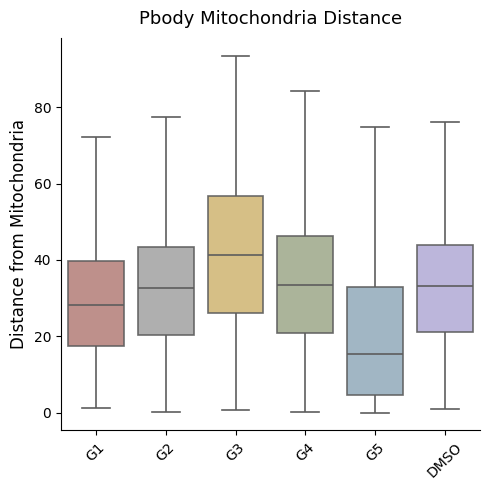

In [42]:
"""
    Create a boxplot that shows the mean distance from mitochondria per picture in each group using the combined_df_2 table 
"""

plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="dist_mito",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)
# labels and aesthetics
plt.ylabel("Distance from Mitochondria", fontsize=12)
plt.xlabel("")
plt.title("Pbody Mitochondria Distance", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()